[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanglab-broad/FuseMap/blob/main/docs/notebooks/11_subregion_discovery.ipynb)

In [ ]:
# Requires a Python 3.9-3.11 runtime. For local setup, see docs/install.rst.
import sys
if not (3, 9) <= sys.version_info[:2] < (3, 12):
    raise RuntimeError("FuseMap requires Python 3.9-3.11. Select a compatible runtime or use the local setup.")
if "google.colab" in sys.modules:
    %pip install -q "fusemap[tutorials]"


# FuseMap Tutorial 11: Discover Finer Tissue Subregions and Microenvironment-Driven Cell States

The annotations that ship with a dataset are only as fine as their authors drew them — but the
FuseMap embeddings trained in [Tutorial 2](2_spatial_integration_cross_tech.ipynb) contain finer
structure than any single annotation. In the FuseMap paper this is exactly how the molCCF mouse
brain atlas was refined into **146 sublevel tissue regions** (e.g. splitting the piriform cortex
into its molecular layers, and the combined LS/CEA annotation into four subregions), and how
**microenvironment-driven cell states** were found (one oligodendrocyte class splitting into
white-matter vs grey-matter states).

This tutorial illustrates related analyses on Tutorial 2's output:

- **Part A — subregion discovery**: subcluster the *tissue* embedding **within one annotated
  main region**, then inspect imputed marker patterns in the sub-domains
- **Part B — microenvironment cell states**: subcluster the *cell* embedding **within one cell
  type**, then show the states differ by spatial context

Run Tutorial 2 first — we reuse its `./output_tutorial2` folder and its raw data folder.

In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
import re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

output_dir = "./output_tutorial2"
if not os.path.exists(os.path.join(output_dir, "ad_celltype_embedding.h5ad")):
    raise FileNotFoundError("Run Tutorial 2 first - its ./output_tutorial2 is the model used here.")

ad_tissue = sc.read_h5ad(os.path.join(output_dir, "ad_tissueregion_embedding.h5ad"))
ad_cell = sc.read_h5ad(os.path.join(output_dir, "ad_celltype_embedding.h5ad"))
gene_embed = sc.read_h5ad(os.path.join(output_dir, "ad_gene_embedding.h5ad"))

# the STARmap section is the one that carries the paper's region / cell-type annotations
star_mask = ad_tissue.obs["file_name"].str.contains("starmap").values
print("cells per main tissue region (annotated section):")
print(ad_tissue.obs.loc[star_mask, "gt_tissue_region_main"].value_counts().head(11))

cells per main tissue region (annotated section):
gt_tissue_region_main
CTX_1            13131
LSX_HY_MB_HB      7928
TH                5594
FbTrt             3133
CTX_2             2997
L1_HPFmo_Mngs     2769
STR               2338
Hbl_VS            1721
HPF_CA            1675
DG                1654
OB_1               401
Name: count, dtype: int64


## Part A: discover subregions inside one annotated region

`CTX_1` (cerebral cortex) is the largest main region on the annotated section — **13,131
cells**, all sharing one label. But the cortex is famously laminated. We subset the **tissue
embedding** to just these cells and cluster *within* the region: any structure that emerges is
sub-annotation structure the label never mentioned.

CTX_1: 13131 cells -> 6 subregions {'0': 4363, '1': 2889, '2': 2757, '3': 1908, '4': 1002, '5': 212}


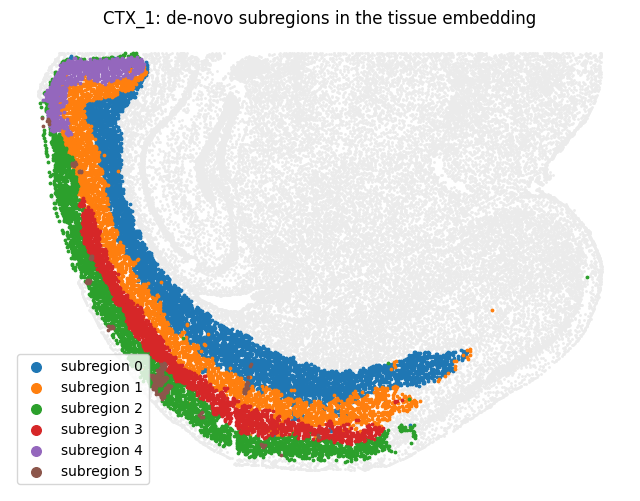

In [3]:
region = "CTX_1"
ad_reg = ad_tissue[star_mask & (ad_tissue.obs["gt_tissue_region_main"] == region).values].copy()
sc.pp.neighbors(ad_reg, use_rep="X", n_neighbors=30)
sc.tl.leiden(ad_reg, resolution=0.2, key_added="subregion", random_state=0)
print(f"{region}: {ad_reg.n_obs} cells -> {ad_reg.obs['subregion'].nunique()} subregions",
      ad_reg.obs["subregion"].value_counts().sort_index().to_dict())

rx, ry = pd.to_numeric(ad_reg.obs["x"]), pd.to_numeric(ad_reg.obs["y"])
bg = (pd.to_numeric(ad_tissue.obs.loc[star_mask, "x"]),
      pd.to_numeric(ad_tissue.obs.loc[star_mask, "y"]))

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(*bg, c="0.92", s=1)
for cl in sorted(ad_reg.obs["subregion"].cat.categories, key=int):
    m = (ad_reg.obs["subregion"] == cl).values
    ax.scatter(rx[m], ry[m], s=3, label=f"subregion {cl}")
ax.legend(markerscale=4)
ax.set_title(f"{region}: de-novo subregions in the tissue embedding")
ax.set_aspect("equal"); ax.axis("off")
plt.show()

The six subclusters are not random speckle — they form **concentric bands** parallel to the
brain surface (cortical layers), plus a thin outermost vascular/pial rim.

**Does each band have its own genes?** The STARmap panel measures only 1,022 genes, but as in
[Tutorial 3](3_gene_spatial_imputation.ipynb) any gene can be imputed through the universal gene
embedding with one matrix product (`E = Z_cell @ Z_gene.T`). We score the 4,000 most-variable
Stereo-seq genes (dropping unannotated `Gm*` / `*Rik` models leaves a **2,290-gene panel**),
z-score each imputed gene across the region, and rank subregion means.

In [4]:
stereo = sc.read_h5ad("./tutorial2_data/stereoseq_mousebrain.h5ad")
sc.pp.highly_variable_genes(stereo, n_top_genes=4000, flavor="seurat_v3")
hvg = [g.upper() for g in stereo.var_names[stereo.var["highly_variable"]]]
unannotated = re.compile(r"(^GM\d)|(RIK$)|(^BC\d)|(^MIR)|(^A[A-Z]\d{6})")
panel = [g for g in hvg if g in gene_embed.obs_names and not unannotated.search(g)]
print("marker panel:", len(panel), "genes")

Z_reg = np.asarray(ad_cell[ad_reg.obs_names].X)        # cell latents of the same cells
imputed_z = Z_reg @ np.asarray(gene_embed[panel].X).T  # (cells x panel), one matrix product
imputed_z = (imputed_z - imputed_z.mean(0)) / (imputed_z.std(0) + 1e-9)

sub = ad_reg.obs["subregion"].astype(str).values
top5 = {}
for cl in sorted(set(sub), key=int):
    score = pd.Series(imputed_z[sub == cl].mean(0), index=panel).sort_values(ascending=False)
    top5[f"subregion {cl}"] = score.head(5).index.tolist()
pd.DataFrame(top5)

marker panel: 2290 genes


,subregion 0,subregion 1,subregion 2,subregion 3,subregion 4,subregion 5
0,COL6A1,ETV1,NECTIN3,RORB,TSHZ2,MYH11
1,CNKSR3,STAC,CALB1,KCNH5,HTR2C,ACTA2
2,NLRP6,SAMD15,CLDN3,COL8A1,HTR4,MYL9
3,FOXP2,LCE3C,CCBE1,PRR16,ANKRD44,DCN
4,HS3ST4,HCN1,MAGI3,LCORL,UNC13C,COL18A1


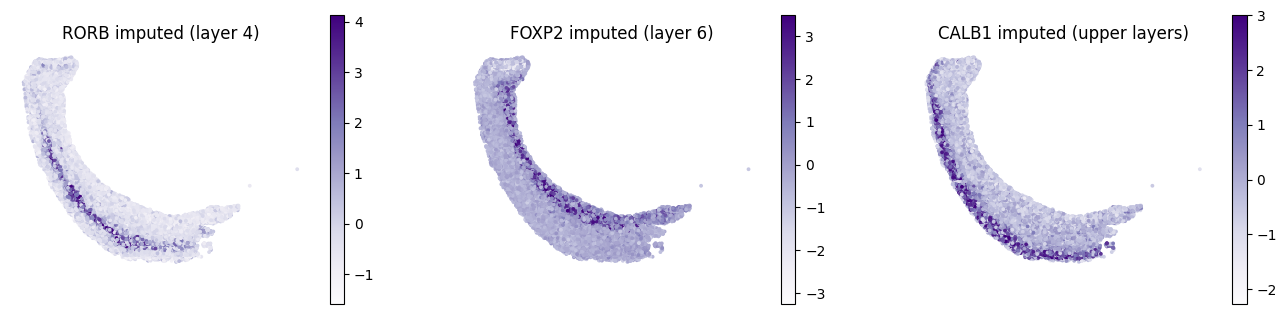

In [5]:
show = [("RORB", "layer 4"), ("FOXP2", "layer 6"), ("CALB1", "upper layers")]
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
for ax, (g, layer) in zip(axes, show):
    v = imputed_z[:, panel.index(g)]
    sca = ax.scatter(rx, ry, c=v, cmap="Purples", s=3, vmax=np.percentile(v, 99))
    ax.set_title(f"{g} imputed ({layer})")
    ax.set_aspect("equal"); ax.axis("off")
    fig.colorbar(sca, ax=ax, shrink=0.75)
plt.show()

The top markers are laminar classics: **RORB** (layer 4) tops subregion 3, **ETV1** (layer 5)
subregion 1, **FOXP2** (layer 6) subregion 0, **CALB1** (superficial layers) subregion 2,
**TSHZ2** marks the medial-posterior domain (subregion 4), and the thin rim (subregion 5) is
unmistakably vascular/pial (**MYH11, ACTA2, DCN**) — patterns consistent with laminar and vascular organization. Imputed
markers come from the same model and are supporting evidence, not independent validation.

For an additional comparison, this dataset also ships the paper's own *sublevel* labels
(`gt_tissue_region`), which we never showed the clustering. The following cross-tabulation shows how de novo clusters overlap
`CTX_A_*` sublevel labels; one-to-one correspondence is not assumed:

In [6]:
dominant = ad_reg.obs.groupby("subregion")["gt_tissue_region"].agg(
    lambda s: f"{s.value_counts().index[0]} ({100 * s.value_counts(normalize=True).iloc[0]:.0f}%)")
pd.DataFrame({"n_cells": ad_reg.obs["subregion"].value_counts().sort_index(),
              "dominant paper sublevel label": dominant})

,n_cells,dominant paper sublevel label
subregion,,
0,4363,CTX_A_12 (33%)
1,2889,CTX_A_7 (31%)
2,2757,CTX_A_3 (61%)
3,1908,CTX_A_8 (71%)
4,1002,CTX_A_5 (88%)
5,212,CTX_A_3 (53%)


## Part B: microenvironment-driven cell states

Same logic, opposite axis: fix the **cell type** and let the **tissue context** vary. The
annotated section has **6,025 oligodendrocytes** (`gt_cell_type_main`) — in the paper this one
class splits into white-matter and grey-matter states. We subcluster the **cell embedding**
within the type, then ask where each state lives (`FbTrt` = fiber tracts, i.e. white matter).

In [7]:
olig_mask = ad_cell.obs["file_name"].str.contains("starmap").values & \
            (ad_cell.obs["gt_cell_type_main"] == "Oligodendrocytes").values
ad_olig = ad_cell[olig_mask].copy()
sc.pp.neighbors(ad_olig, use_rep="X", n_neighbors=30)
sc.tl.leiden(ad_olig, resolution=0.2, key_added="state", random_state=0)
print("state sizes:", ad_olig.obs["state"].value_counts().sort_index().to_dict())
print("baseline: {:.1f}% of all oligodendrocytes sit in FbTrt".format(
    100 * (ad_olig.obs["gt_tissue_region_main"] == "FbTrt").mean()))

ctab = pd.crosstab(ad_olig.obs["state"], ad_olig.obs["gt_tissue_region_main"].astype(str),
                   normalize="index").mul(100).round(1)
ctab[["FbTrt", "CTX_1", "TH", "LSX_HY_MB_HB", "STR", "Hbl_VS"]]  # % of state in each region

state sizes: {'0': 3290, '1': 2112, '2': 570, '3': 53}
baseline: 35.3% of all oligodendrocytes sit in FbTrt


gt_tissue_region_main,FbTrt,CTX_1,TH,LSX_HY_MB_HB,STR,Hbl_VS
state,,,,,,
0,31.8,17.2,11.8,25.9,3.0,3.9
1,35.6,12.8,21.1,17.5,5.7,3.7
2,57.7,9.6,2.8,6.8,2.5,17.5
3,3.8,0.0,1.9,94.3,0.0,0.0


The states are ordered along a grey-matter-to-white-matter axis: **57.7%** of state 2 sits in
fiber tracts versus the **35.3%** baseline (1.6x enrichment), while state 0 lives mostly in grey
matter (68% outside `FbTrt`). (The 53-cell state 3 is a bonus QC catch — its huge imputed
**GAD1** below suggests possible mixed or mis-segmented material. Check measured markers
and segmentation before excluding these cells.)

If the split is really white- vs grey-matter, myelin genes (**MBP, PLP1, MOBP**) should rise
along it and neuronal/synaptic environment genes (**GAD1, SYT4, SNAP25**) should fall — again
checked purely by imputation, since none of the six genes needs to be in the STARmap panel.

state-wise mean imputed expression (z-score):
        MBP  PLP1  MOBP  GAD1  SYT4  SNAP25
state                                      
0     -0.46 -0.61 -0.56  0.15  0.26    0.34
1      0.43  0.61  0.47 -0.25 -0.09   -0.29
2      1.10  1.34  1.54 -0.62 -1.14   -1.02
3     -0.04 -0.70 -0.81  6.93 -0.06    1.30


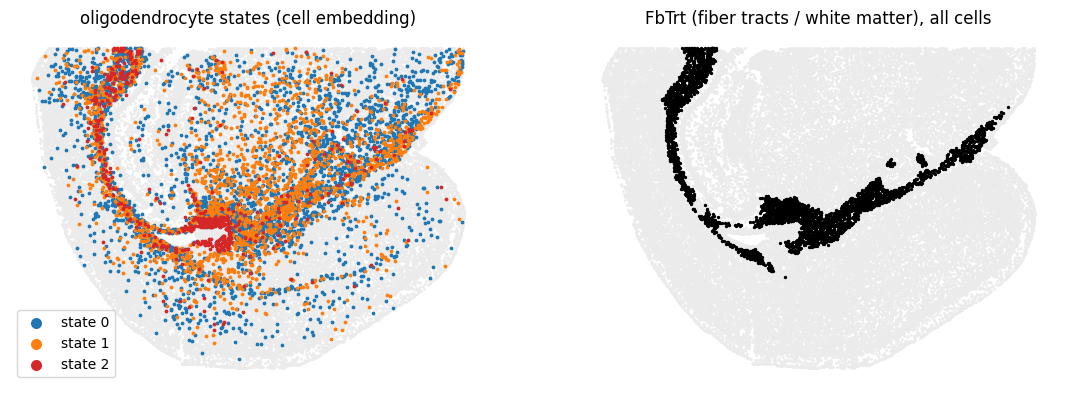

In [8]:
genes = ["MBP", "PLP1", "MOBP", "GAD1", "SYT4", "SNAP25"]  # myelin vs grey-matter
vals = np.asarray(ad_olig.X) @ np.asarray(gene_embed[genes].X).T
vals = (vals - vals.mean(0)) / vals.std(0)
imp = pd.DataFrame(vals, columns=genes)
imp["state"] = ad_olig.obs["state"].values
print("state-wise mean imputed expression (z-score):")
print(imp.groupby("state").mean().round(2))

ox, oy = pd.to_numeric(ad_olig.obs["x"]), pd.to_numeric(ad_olig.obs["y"])
fb = star_mask & (ad_tissue.obs["gt_tissue_region_main"] == "FbTrt").values
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
axes[0].scatter(*bg, c="0.92", s=1)
for cl, col in [("0", "tab:blue"), ("1", "tab:orange"), ("2", "tab:red")]:
    m = (ad_olig.obs["state"] == cl).values
    axes[0].scatter(ox[m], oy[m], c=col, s=3, label=f"state {cl}")
axes[0].legend(markerscale=4)
axes[0].set_title("oligodendrocyte states (cell embedding)")
axes[1].scatter(*bg, c="0.92", s=1)
axes[1].scatter(pd.to_numeric(ad_tissue.obs.loc[fb, "x"]),
                pd.to_numeric(ad_tissue.obs.loc[fb, "y"]), c="k", s=2)
axes[1].set_title("FbTrt (fiber tracts / white matter), all cells")
for ax in axes:
    ax.set_aspect("equal"); ax.axis("off")
plt.show()

In the saved example, imputed MBP z-scores rise from state 0 to state 2
(-0.46, +0.43, +1.10), and the myelin-high state follows major fiber tracts.
This association is consistent with spatially varying oligodendrocyte states;
it does not establish that the microenvironment caused the differences.

## From miniature to atlas

Clustering within an annotation can propose finer subdivisions. Imputed markers
help interpret them, but the paper's 146-region atlas also used distinct spatial
organization, cross-section and cross-platform consistency, measured markers,
and anatomical registration. Those checks are needed before declaring new
anatomical regions. The paper split the combined LS/CEA annotation into four
subregions in total.

To apply this example to new data, map to molCCF
([Tutorial 5](5_map_new_dataset_molCCF.ipynb)), transfer the annotations, and inspect
cell/tissue embeddings with the reference gene embedding. Validate candidate
states using independent data where available.
